In [1]:
import pathlib

from dtaidistance import dtw
from dtaidistance import dtw_visualisation as dtwvis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import re
import tqdm

In [18]:
from dtaidistance import dtw_visualisation as dtwvis

In [2]:
DATA = pathlib.Path("..") / "sub_bytes.csv"
df = pd.read_csv(DATA)
df.head()

,trace_file,secret,mem0,mem1,mem2,mem3,mem4,mem5,mem6,mem7,...,mem76,mem77,mem78,mem79,mem80,mem81,mem82,mem83,mem84,mem85
0,trace_10000369368611929355.txt,1.000037e+19,5670672,5670648,5670668,5670668,5670648,5670666,5670666,4276267,...,5670666,4276394,5670667,5670648,5670648,5670668,5670668,5670668,5670672,5670680
1,trace_10000530007239268649.txt,1.000053e+19,5670672,5670648,5670668,5670668,5670648,5670666,5670666,4276297,...,5670666,4276394,5670667,5670648,5670648,5670668,5670668,5670668,5670672,5670680
2,trace_10000664852027228354.txt,1.000066e+19,5670672,5670648,5670668,5670668,5670648,5670666,5670666,4276450,...,5670666,4276394,5670667,5670648,5670648,5670668,5670668,5670668,5670672,5670680
3,trace_10000875258175976375.txt,1.000088e+19,5670672,5670648,5670668,5670668,5670648,5670666,5670666,4276439,...,5670666,4276394,5670667,5670648,5670648,5670668,5670668,5670668,5670672,5670680
4,trace_10002101362539977763.txt,1.000210e+19,5670672,5670648,5670668,5670668,5670648,5670666,5670666,4276291,...,5670666,4276394,5670667,5670648,5670648,5670668,5670668,5670668,5670672,5670680


# 1. Split the data + Train the Models

We do a 50-50 split. We train our pretrain model on the first 999 traces and will evaluate the Dynamic Time Warp on the other 1000 traces

* `_prepare` For Training
* `_eval` For evaluation of TimeWarping

In [3]:
# Splittin the data
X = df.iloc[:, 2:].values
y = np.array([re.findall(r'\d+', line)[0] for line in  df.trace_file.values], dtype=np.uint64)
# Split y into bytes of the secret
y_bytes = [(y >> (i*8)) & 0xff for i in range(8)]
y_bytes = pd.DataFrame(y_bytes).T
split = 10000
X_prepare, X_eval = X[:split], X[split:]
y_prepare, y_eval = y_bytes[:split], y_bytes[split:].reset_index(drop=True)

del X, y, y_bytes # don't confuse yourself in the future

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X_prepare, y_prepare, test_size=0.2, random_state=0)
clf = LinearRegression().fit(X_train, y_train)

In [5]:
print("Test-Accuracy per byte:")
pd.DataFrame(clf.predict(X_test).round() == y_test.values).sum() / len(y_test.values)

Test-Accuracy per byte:


0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
5    1.0
6    1.0
7    1.0
dtype: float64

# Methodology

In real side-channels, some data access might be missing. For our model to work, we need a method to impute the missing data. The method we choose is Dynamic Time Warping.

We will compare the following mehthods:
1. Optimal imputing (We know the missing indices and just impute the data from another trace)
2. Dynamic Time Warping 
3. Dynamic Time Warping with static window
4. Dynamic Time Warping with dynamic window (window-size = missing length)



In [7]:
def drop_trace(trace, prob):
    """Drops some part of the trace with a probability of prob"""
    keep = np.random.random(len(trace)) > prob
    dropped = [i for i in range(len(keep)) if not keep[i]]
    return trace[keep], dropped



array([5670672, 5670648, 5670668, 5670668, 5670648, 5670666, 5670666,
       4276267, 5670667, 5670648, 5670648, 5670668, 5670668, 5670668,
       5670648, 5670666, 5670666, 4276445, 5670667, 5670648, 5670648,
       5670668, 5670668, 5670668, 5670648, 5670666, 4276463, 5670667,
       5670648, 5670648, 5670668, 5670668, 5670668, 5670648, 5670666,
       5670666, 4276478, 5670667, 5670648, 5670648, 5670668, 5670668,
       5670668, 5670648, 5670666, 5670666, 4276500, 5670667, 5670648,
       5670648, 5670668, 5670668, 5670668, 5670648, 5670666, 4276370,
       5670667, 5670648, 5670648, 5670668, 5670668, 5670668, 5670648,
       5670666, 4276456, 5670667, 5670648, 5670648, 5670668, 5670668,
       5670668, 5670648, 5670666, 5670666, 4276394, 5670667, 5670648,
       5670648, 5670668, 5670668, 5670672, 5670680])

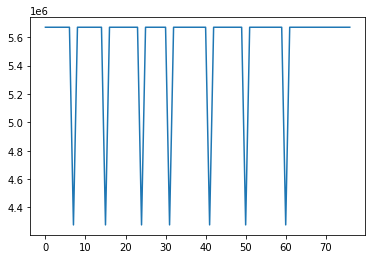

In [56]:
dropped = drop_trace(X_prepare[0], 0.05)[0]
while (sum(dropped == X_prepare[0][-9]) > 0):
    print(sum(dropped == X_prepare[0][-9]))
    dropped = drop_trace(X_prepare[0], 0.05)[0]
plt.plot(dropped)

In [41]:
full[-9]

4276394

In [48]:
sum(X_prepare[0] == X_prepare[0][-9])


1

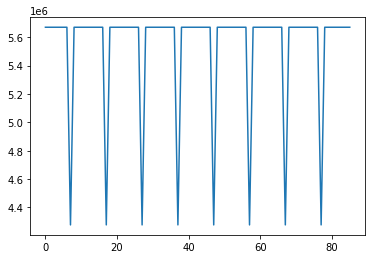

In [14]:
full = X_prepare[1]
plt.plot(full)

In [57]:
path = dtw.warping_path(full, dropped, window = 1)

path_inf = dtw.warping_path(full, dropped)



The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


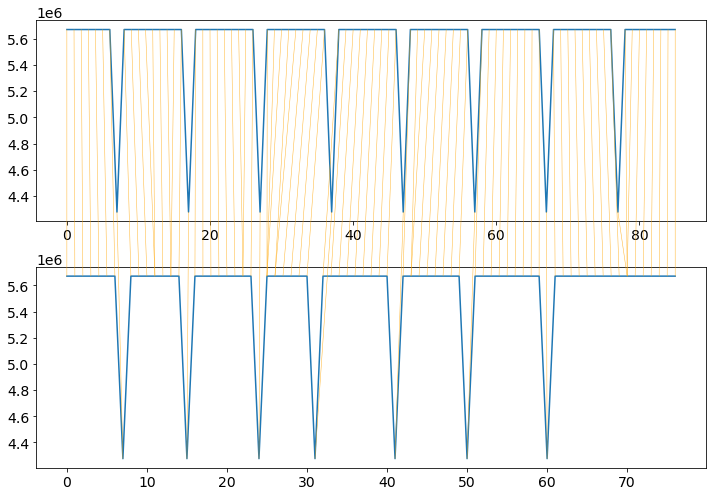

In [61]:
with plt.style.context('./arend.mplstyle'):
    fig, ax = plt.subplots(2, 1)
    dtwvis.plot_warping(full, dropped, path, fig = fig, axs = ax[:2])
    fig.savefig("warp_best.pdf")
    fig.savefig("warp_best.eps")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


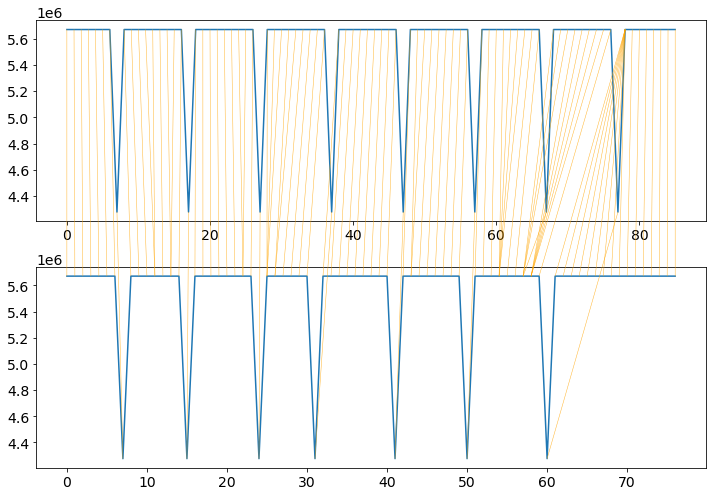

In [62]:
with plt.style.context('./arend.mplstyle'):
    fig, ax = plt.subplots(2, 1)
    dtwvis.plot_warping(full, dropped, path_inf, fig = fig, axs = ax[:2])
    fig.savefig("warp_fail.pdf")
    fig.savefig("warp_fail.eps")

In [28]:
plt.subplots?

Signature:
plt.subplots(
    nrows=1,
    ncols=1,
    *,
    sharex=False,
    sharey=False,
    squeeze=True,
    subplot_kw=None,
    gridspec_kw=None,
    **fig_kw,
)
Docstring:
Create a figure and a set of subplots.

This utility wrapper makes it convenient to create common layouts of
subplots, including the enclosing figure object, in a single call.

Parameters
----------
nrows, ncols : int, default: 1
    Number of rows/columns of the subplot grid.

sharex, sharey : bool or {'none', 'all', 'row', 'col'}, default: False
    Controls sharing of properties among x (*sharex*) or y (*sharey*)
    axes:

    - True or 'all': x- or y-axis will be shared among all subplots.
    - False or 'none': each subplot x- or y-axis will be independent.
    - 'row': each subplot row will share an x- or y-axis.
    - 'col': each subplot column will share an x- or y-axis.

    When subplots have a shared x-axis along a column, only the x tick
    labels of the bottom subplot are created. Similarly, 

In [22]:
dtwvis.plot_warping?

Signature:
dtwvis.plot_warping(
    s1,
    s2,
    path,
    filename=None,
    fig=None,
    axs=None,
    series_line_options=None,
    warping_line_options=None,
)
Docstring:
Plot the optimal warping between to sequences.

:param s1: From sequence.
:param s2: To sequence.
:param path: Optimal warping path.
:param filename: Filename path (optional).
:param fig: Matplotlib Figure object
:param axs: Array of Matplotlib axes.Axes objects (length == 2)
:param series_line_options: Dictionary of options to pass to matplotlib plot
    None will not pass any options
:param warping_line_options: Dictionary of options to pass to matplotlib ConnectionPatch
    None will use {'linewidth': 0.5, 'color': 'orange', 'alpha': 0.8}
:return: Figure, list[Axes]
File:      ~/.local/lib/python3.10/site-packages/dtaidistance/dtw_visualisation.py
Type:      function


In [7]:
def impute_data(incomplete, dynamic_window_size=False, **kwargs):
    """Imputes incomplete data against one concrete example."""
    complete = X_prepare[0]
    if dynamic_window_size:
        window = len(complete) - len(incomplete)
        path = dtw.warping_path(incomplete, complete, window = window)
        
    else:
        path = dtw.warping_path(incomplete, complete, **kwargs)
    
    # Create mapping y-index -> x-index
    mapping = {y:x for x,y in path}
    out = []
    for i in range(len(complete)):
        if i in mapping:
            out.append(incomplete[mapping[i]])
        else:
            out.append(complete[i])
    
    return np.array(out)

trace, _ = drop_trace(X_prepare[0], 0.05)
assert len(impute_data(trace)) == len(X_prepare[0])

In [8]:

results = {}
y_eval = y_eval[:1000]
X_eval = X_eval[:1000]
for prob in tqdm.tqdm(np.linspace(0.05, 0.5, 10)):
    X_deleted = []
    dropped = []

    for x in X_eval:
        new_trace, new_dropped = drop_trace(x, prob)
        X_deleted.append(new_trace)
        dropped.append(new_dropped)

    # 1. Perfect imputation (with known missing idx)
    complete = X_prepare[0] # Use this for imputaion
    X_perfect = []
    for x, d in zip(X_deleted, dropped):
        for idx in d:
            x = np.insert(x, idx, complete[idx])
        X_perfect.append(x)

    # 2. Dynamic Time Warping
    
    X_dtw = [impute_data(x) for x in X_deleted]
    # 3. Dynamic Time Warping dynamic
    X_dtw_window = [impute_data(x, dynamic_window_size=True) for x in X_deleted]
    # 4. Dynamic Time Warping static
    X_dtw_window_static = [impute_data(x, window=1) for x in X_deleted]
    # 5. Dynamic Time Warping Window Size 0
    X_dtw_window_0 = [impute_data(x, window=0) for x in X_deleted]
    names = [
        (X_perfect, "Perfect imputation"),
        (X_dtw, "Dynamic Time Warping"),
        (X_dtw_window, "Dynamic Time Warping dynamic"),
        (X_dtw_window_static, "Dynamic Time Warping window = 1"),
        (X_dtw_window_0, "Dynamic Time Warping window = 0")
    ]

    
    for X, name in names:
        X = pd.DataFrame(X)
        tmp = clf.predict(X).round() == y_eval
        tmp.to_csv(f"{prob}_{name}.csv")
        


100%|████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [04:03<00:00, 24.31s/it]
